# Initial Data Exploration

The objective of this notebook is to perform a first exploration of the cleaned market data used in Quantitative Decision Lab.

This analysis focuses on:

- checking the structure and quality of the data;
- comparing normalized asset price evolution;
- computing daily returns;
- analysing volatility differences across assets;
- studying correlations between asset classes.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv(
    "../data/processed/adjusted_close_prices.csv",
    index_col=0,
    parse_dates=True,
)

prices.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-02,24.192606,114.080002,46.274326,39.681740,0.482423,169.687836,93.001488,57.145554
2015-01-05,23.511061,115.800003,44.837730,39.316837,0.474275,166.623352,94.462410,55.581959
2015-01-06,23.513273,117.120003,43.675125,38.739761,0.459895,165.053955,96.164352,55.286457
2015-01-07,23.842985,116.430000,43.741779,39.231964,0.458697,167.110672,95.974449,55.846649
2015-01-08,24.759083,115.940002,44.719234,40.386105,0.475952,170.076096,94.703430,56.776207


In [20]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2888 non-null   float64
 1   GLD     2888 non-null   float64
 2   JPM     2888 non-null   float64
 3   MSFT    2888 non-null   float64
 4   NVDA    2888 non-null   float64
 5   SPY     2888 non-null   float64
 6   TLT     2888 non-null   float64
 7   XOM     2888 non-null   float64
dtypes: float64(8)
memory usage: 203.1 KB


In [21]:
prices.describe()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000
mean,113.172358,176.975661,126.666023,213.945885,39.601078,351.505373,99.778523,71.264548
std,80.072936,79.677360,74.417228,145.745529,58.670267,155.443535,15.701657,29.273194
min,20.565866,100.500000,40.268799,34.284489,0.458697,154.161636,73.974899,23.823559
25%,37.284087,121.250000,76.923092,76.223078,3.876708,223.546768,88.114336,52.061780
50%,111.987671,162.014999,104.142883,202.127190,12.428802,312.817917,95.156670,56.742485
75%,173.275269,183.669998,145.097599,325.217789,43.405582,432.806847,106.753151,97.786686
max,315.200012,495.899994,335.119995,538.658569,235.465576,757.618225,143.226562,170.313995


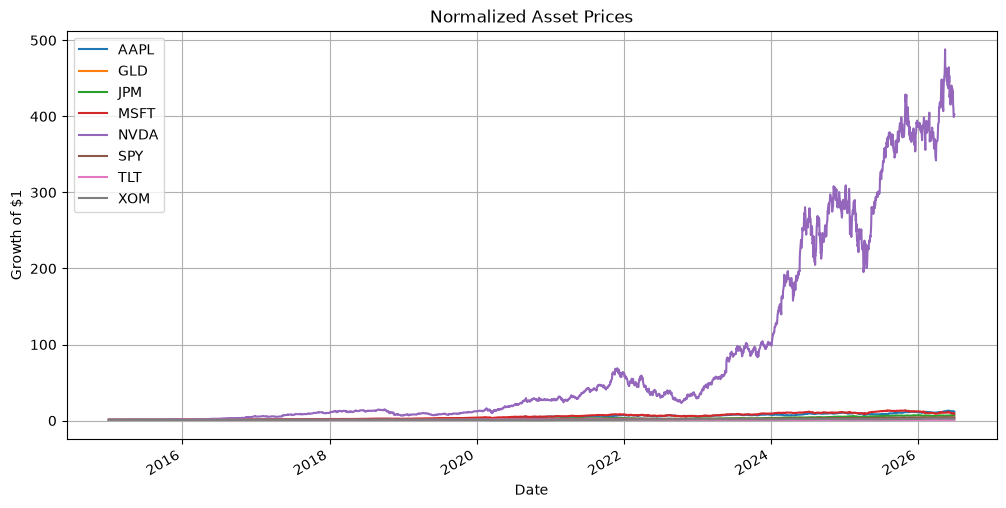

In [22]:
normalized_prices = prices / prices.iloc[0]

normalized_prices.plot(figsize=(12, 6))
plt.title("Normalized Asset Prices")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [23]:
returns = pd.read_csv(
    "../data/processed/simple_returns.csv",
    index_col=0,
    parse_dates=True,
)

returns.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-05,-0.028172,0.015077,-0.031045,-0.009196,-0.016890,-0.018060,0.015709,-0.027362
2015-01-06,0.000094,0.011399,-0.025929,-0.014678,-0.030318,-0.009419,0.018017,-0.005317
2015-01-07,0.014022,-0.005891,0.001526,0.012705,-0.002605,0.012461,-0.001975,0.010133
2015-01-08,0.038422,-0.004209,0.022346,0.029418,0.037618,0.017745,-0.013243,0.016645
2015-01-09,0.001073,0.011385,-0.017387,-0.008405,0.004028,-0.008014,0.010953,-0.001410


In [25]:
returns.describe()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
count,2887.000000,2887.000000,2887.000000,2887.000000,2887.000000,2887.000000,2887.000000,2887.000000
mean,0.001015,0.000458,0.000827,0.000920,0.002538,0.000572,0.000022,0.000453
std,0.018092,0.010108,0.017031,0.017162,0.030422,0.011121,0.009353,0.017336
min,-0.128647,-0.102742,-0.149649,-0.147390,-0.187559,-0.109424,-0.066683,-0.122248
25%,-0.007326,-0.004763,-0.007038,-0.006990,-0.012591,-0.003701,-0.005608,-0.008217
50%,0.000951,0.000557,0.000697,0.000847,0.002576,0.000655,0.000338,0.000367
75%,0.009889,0.005541,0.008950,0.009445,0.017553,0.005930,0.005492,0.009192
max,0.153289,0.063587,0.180124,0.142169,0.298067,0.105019,0.075195,0.126868


In [ ]:
daily_volatility = returns.std().sort_values(ascending=False)
daily_volatility

AAPL    0.001015
GLD     0.000458
JPM     0.000827
MSFT    0.000920
NVDA    0.002538
SPY     0.000572
TLT     0.000022
XOM     0.000453
dtype: float64

In [29]:
daily_volatility * (252 ** 0.5)

NVDA    0.482933
AAPL    0.287205
XOM     0.275201
MSFT    0.272445
JPM     0.270359
SPY     0.176542
GLD     0.160462
TLT     0.148476
dtype: float64

In [27]:
returns.mean()

AAPL    0.001015
GLD     0.000458
JPM     0.000827
MSFT    0.000920
NVDA    0.002538
SPY     0.000572
TLT     0.000022
XOM     0.000453
dtype: float64

In [28]:
returns.mean() * 252

AAPL    0.255671
GLD     0.115398
JPM     0.208304
MSFT    0.231761
NVDA    0.639539
SPY     0.144265
TLT     0.005633
XOM     0.114077
dtype: float64

In [15]:
correlation_matrix = returns.corr()
correlation_matrix

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
AAPL,1.000000,0.027569,0.416703,0.639026,0.518347,0.738233,-0.107901,0.288796
GLD,0.027569,1.000000,-0.076028,0.029909,0.037050,0.066738,0.258098,0.038828
JPM,0.416703,-0.076028,1.000000,0.421567,0.336263,0.711699,-0.319070,0.513797
MSFT,0.639026,0.029909,0.421567,1.000000,0.589054,0.762472,-0.115726,0.248775
NVDA,0.518347,0.037050,0.336263,0.589054,1.000000,0.646578,-0.073230,0.183292
SPY,0.738233,0.066738,0.711699,0.762472,0.646578,1.000000,-0.173577,0.504830
TLT,-0.107901,0.258098,-0.319070,-0.115726,-0.073230,-0.173577,1.000000,-0.239926
XOM,0.288796,0.038828,0.513797,0.248775,0.183292,0.504830,-0.239926,1.000000


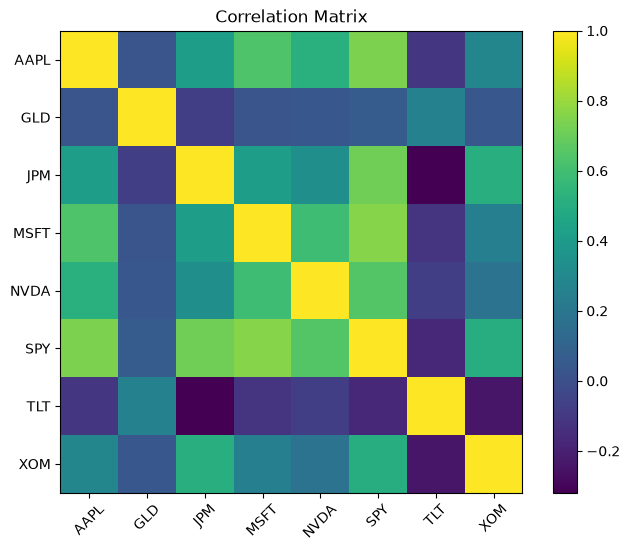

In [16]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
)

plt.title("Correlation Matrix")
plt.show()